# Sept-Iles Layered Intrusion ca. 565 Ma paleomagnetic pole

## Geologic context

The Sept-Iles layered mafic intrusion is a large (~5000 km²), funnel-shaped
gabbro-anorthosite-syenite-granite body that intrudes Grenville basement on the
north shore of the St. Lawrence River, Quebec, along the St. Lawrence rift system
(Tanczyk, Lapointe, Morris & Schmidt, 1987). Igneous layering is subhorizontal,
so the rocks are treated in situ with tilt-correction applied to paleomagnetic data. The intrusion is cut by numerous later diabase dykes. A U-Pb age of 565 ± 4 Ma on zircon from granophyric zones within the
layered gabbros (Higgins & van Breemen, 1998) dates emplacement; Bono & Tarduno
(2015) refer to the suite as the ca. 565 Ma Sept-Iles intrusive suite.

## Two magnetization components (Tanczyk et al., 1987)

Thermal and AF demagnetization isolated two remanences:

- **Remanence A** The gabbro and anorthosite carry a shallow,
  northwest-and-up direction (D=333°, I=−29°), carried by fine-grained magnetite
  and unblocking at 550-580 °C — interpreted as a primary thermochemical remanence
  acquired on initial cooling of the intrusion. Pole 20°N/141°E (= −20°/321°). **This is the
  Sept-Iles pole.**
- **Remanence B** The cross-cutting diabase dykes, and the
  gabbro/anorthosite host immediately adjacent to the dyke contacts, carry a
  steep direction (D=188°, I=−85°; pole 59°S/116°E). Away from the dyke contacts
  the host retains Remanence A — interpreted as a positive inverse baked-contact
  test, indicating that A predates the dyke event and is the older magnetization.
  
## Age constraints

565 ± 4 Ma weighted mean of <sup>207</sup>Pb/<sup>206</sup>Pb dates from two zircon grains dated via U-Pb ID-TIMS in Higgins and van Breemen, 1998. Legros et al., 2026 obtained two more LA-ICP-MS dates of 563.9±1.9 Ma and 564.7±2.3 Ma (concordia ages not weighted mean ages). These dates are within the uncertainty of the 565 ± 4 Ma age from Higgins and van Breemen, 1998.

Higgins, M. D., & van Breemen, O. (1998). The Age of the Sept Iles Layered Mafic Intrusion, Canada: Implications for the Late Neoproterozoic/Cambrian History of Southeastern Canada. The Journal of Geology, 106(4), 421–432. https://doi.org/10.1086/516033

Legros, H., Kieffer, M. A., Dare, S. A. S., Namur, O., Higgins, M. D., Savard, D., & Glorie, S. (2026). Apatite geochronology of the Sept-Iles Intrusive Suite (Grenville province, Canada) reveals two magmatic episodes 55 Myrs apart related to plume arrival and subsequent rifting. Contributions to Mineralogy and Petrology, 181(4), 32. https://doi.org/10.1007/s00410-026-02320-1

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Site means are loaded from `../data/565_Sept_Iles/sites.txt`. Component `A` is the
primary intrusion remanence (10 sites); `B-host` (12 sites) and `B-dyke` (4 sites)
are the secondary dyke/contact remanence. Directions are in situ (subhorizontal
layering).

In [2]:
sites_geo, _ = pt.load_magic_sites('../data/565_Sept_Iles/sites.txt')
print('components:', sites_geo['dir_comp_name'].value_counts().to_dict())
A = sites_geo[sites_geo['dir_comp_name'] == 'A'].reset_index(drop=True)
study_lat, study_lon = 50.2, 293.5
print(f'\n{len(A)} Remanence-A sites')
A[['site', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

components: {'B-host': 12, 'A': 10, 'B-dyke': 4}

10 Remanence-A sites


,site,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon
0,SI1,320,-34,61.0,5.0,13,12.7,152.1
1,SI3,336,-40,61.0,7.0,9,14.0,136.2
2,SI4a,331,-41,16.0,31.0,3,12.0,140.5
3,SI8a,334,-21,21.0,17.0,5,24.8,141.8
4,SI10a,342,-24,57.0,16.0,3,25.3,133.0
5,SI11a,326,-39,100.0,8.0,6,11.7,145.5
6,SI13a,323,-30,28.0,18.0,4,16.1,150.5
7,SI14,330,-10,173.0,6.0,5,29.0,148.2
8,SI15a,344,-38,NaN,NaN,2,17.1,129.1
9,SI17a,343,-10,NaN,NaN,1,32.8,133.8


In [3]:
pt.plot_site_map(sites_geo)

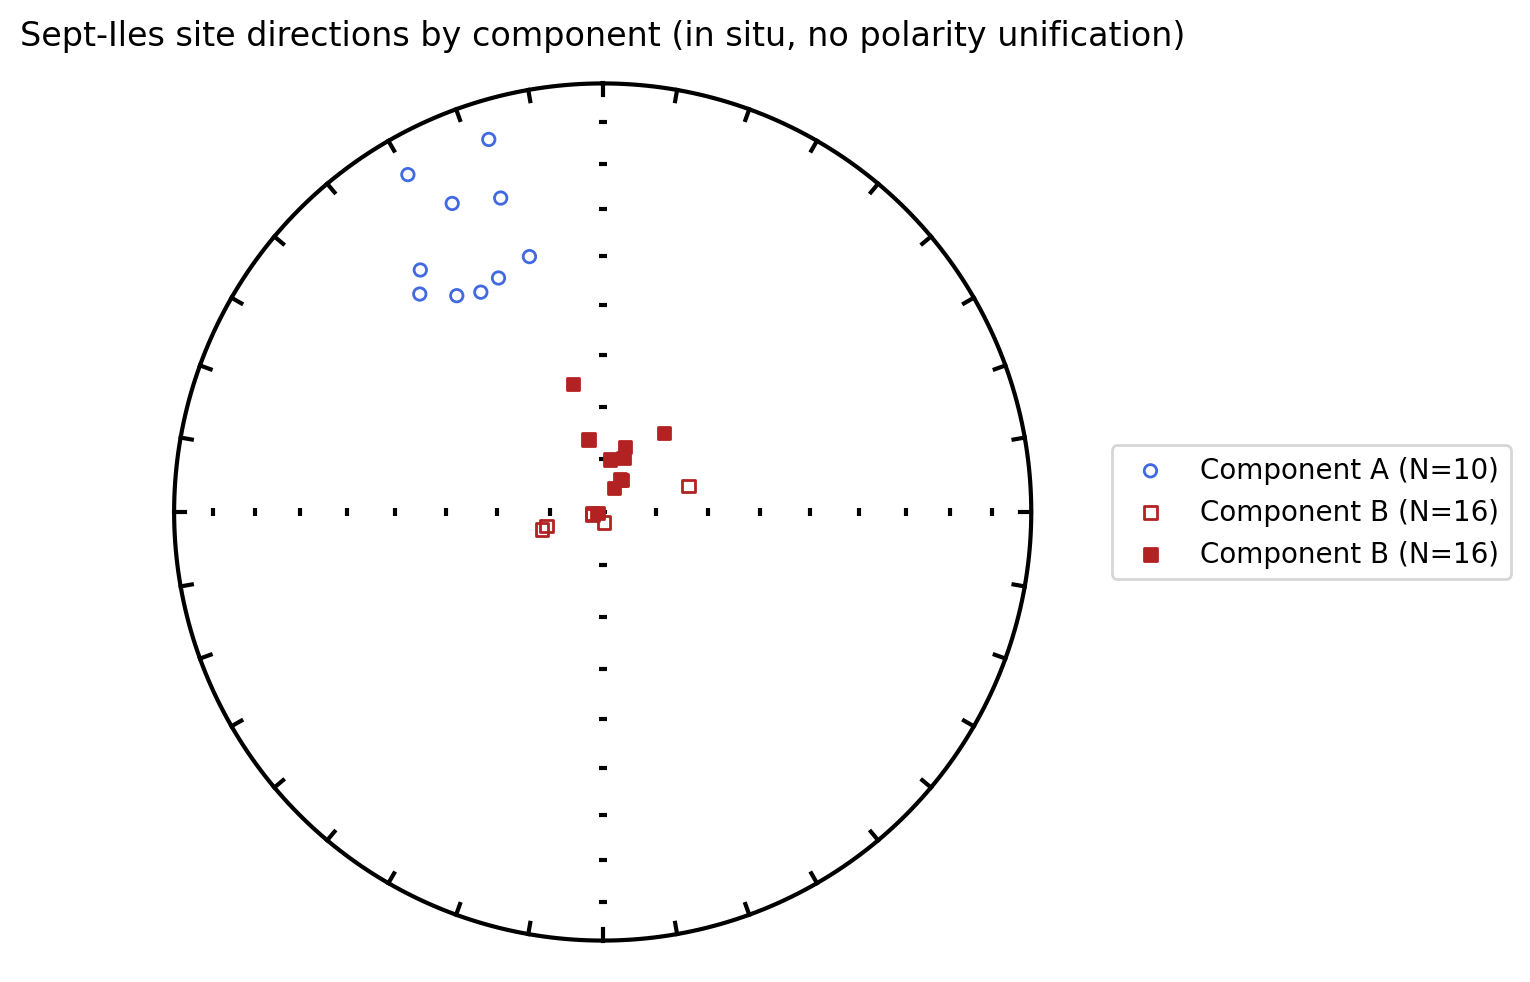

In [4]:
# all site directions colored by component, in situ (no polarity unification:
# downward directions are filled, upward directions open)
B = sites_geo[sites_geo['dir_comp_name'].str.startswith('B')]
ipmag.plot_net()
ipmag.plot_di(A['dir_dec'].tolist(), A['dir_inc'].tolist(),
              color='royalblue', marker='o', label=f'Component A (N={len(A)})')
ipmag.plot_di(B['dir_dec'].tolist(), B['dir_inc'].tolist(),
              color='firebrick', marker='s', label=f'Component B (N={len(B)})')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('Sept-Iles site directions by component (in situ, no polarity unification)')
plt.show()

## A-component pole

The A-component VGPs are reported in the southern-hemisphere convention of the
prior compilation (Laurentia lay near the equator in the Ediacaran).

Remanence-A pole: -19.7 / 321.2, A95 6.5, K 56.9, N 10
Tanczyk et al. (1987): 20 N / 141 E (= -20 / 321); prior compilation GPMDB 1752: -20/321, A95 6.7


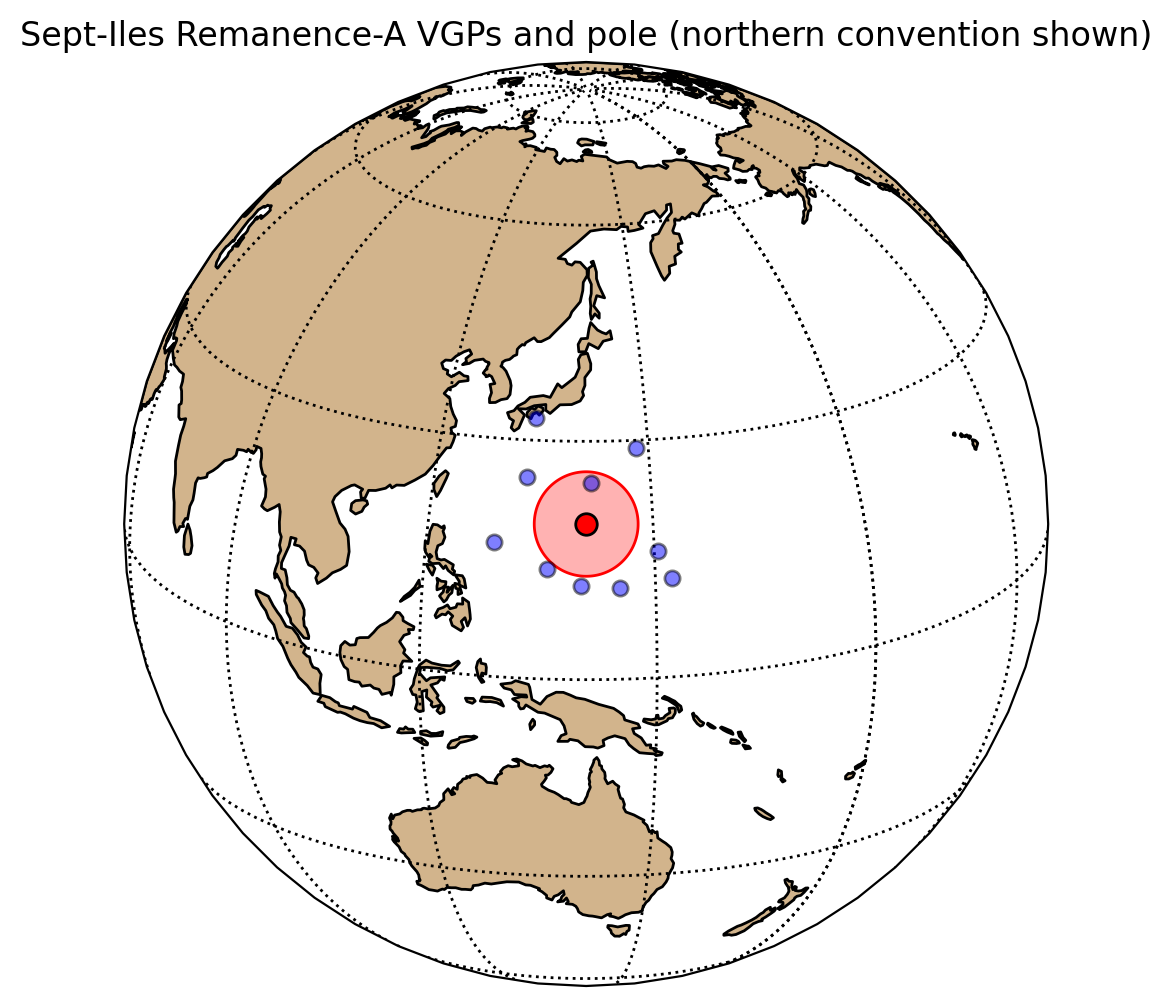

In [5]:
vgp_block, pole_north = pt.compute_mean_pole(A, unify_polarity=False)
pole_mean = {'inc': -pole_north['inc'], 'dec': (pole_north['dec'] + 180) % 360,
             'alpha95': pole_north['alpha95'], 'k': pole_north['k'], 'n': pole_north['n']}
print(f"Remanence-A pole: {pole_mean['inc']:.1f} / {pole_mean['dec']:.1f}, "
      f"A95 {pole_mean['alpha95']:.1f}, K {pole_mean['k']:.1f}, N {int(pole_mean['n'])}")
print('Tanczyk et al. (1987): 20 N / 141 E (= -20 / 321); prior compilation GPMDB 1752: -20/321, A95 6.7')
ax = pt.plot_vgps_and_pole(vgp_block, pole_north, central_longitude=pole_north['dec'],
                           central_latitude=pole_north['inc'], figsize=(6, 6))
plt.title('Sept-Iles Remanence-A VGPs and pole (northern convention shown)')
plt.show()

In [6]:
dir_block, dir_mean = pt.compute_mean_direction(A, unify_polarity=False)
ipmag.print_direction_mean(dir_mean)

Dec: 333.1  Inc: -29.0
Number of directions in mean (n): 10
Angular radius of 95% confidence (a_95): 8.5
Precision parameter (k) estimate: 33.6


## Inverse baked-contact test (Tanczyk et al., 1987)

The two remanences are spatially organized by the dykes: the diabase dykes
(`B-dyke`) and the host rock within a metre or so of a dyke contact (`B-host`)
carry the steep Remanence B, whereas the intrusion away from the dykes retains the
shallow Remanence A. Because the older intrusion retains its own magnetization
where the younger dykes did not reheat it, this is interpreted as a positive inverse baked-contact test, indicating that
Remanence A predates the dykes.

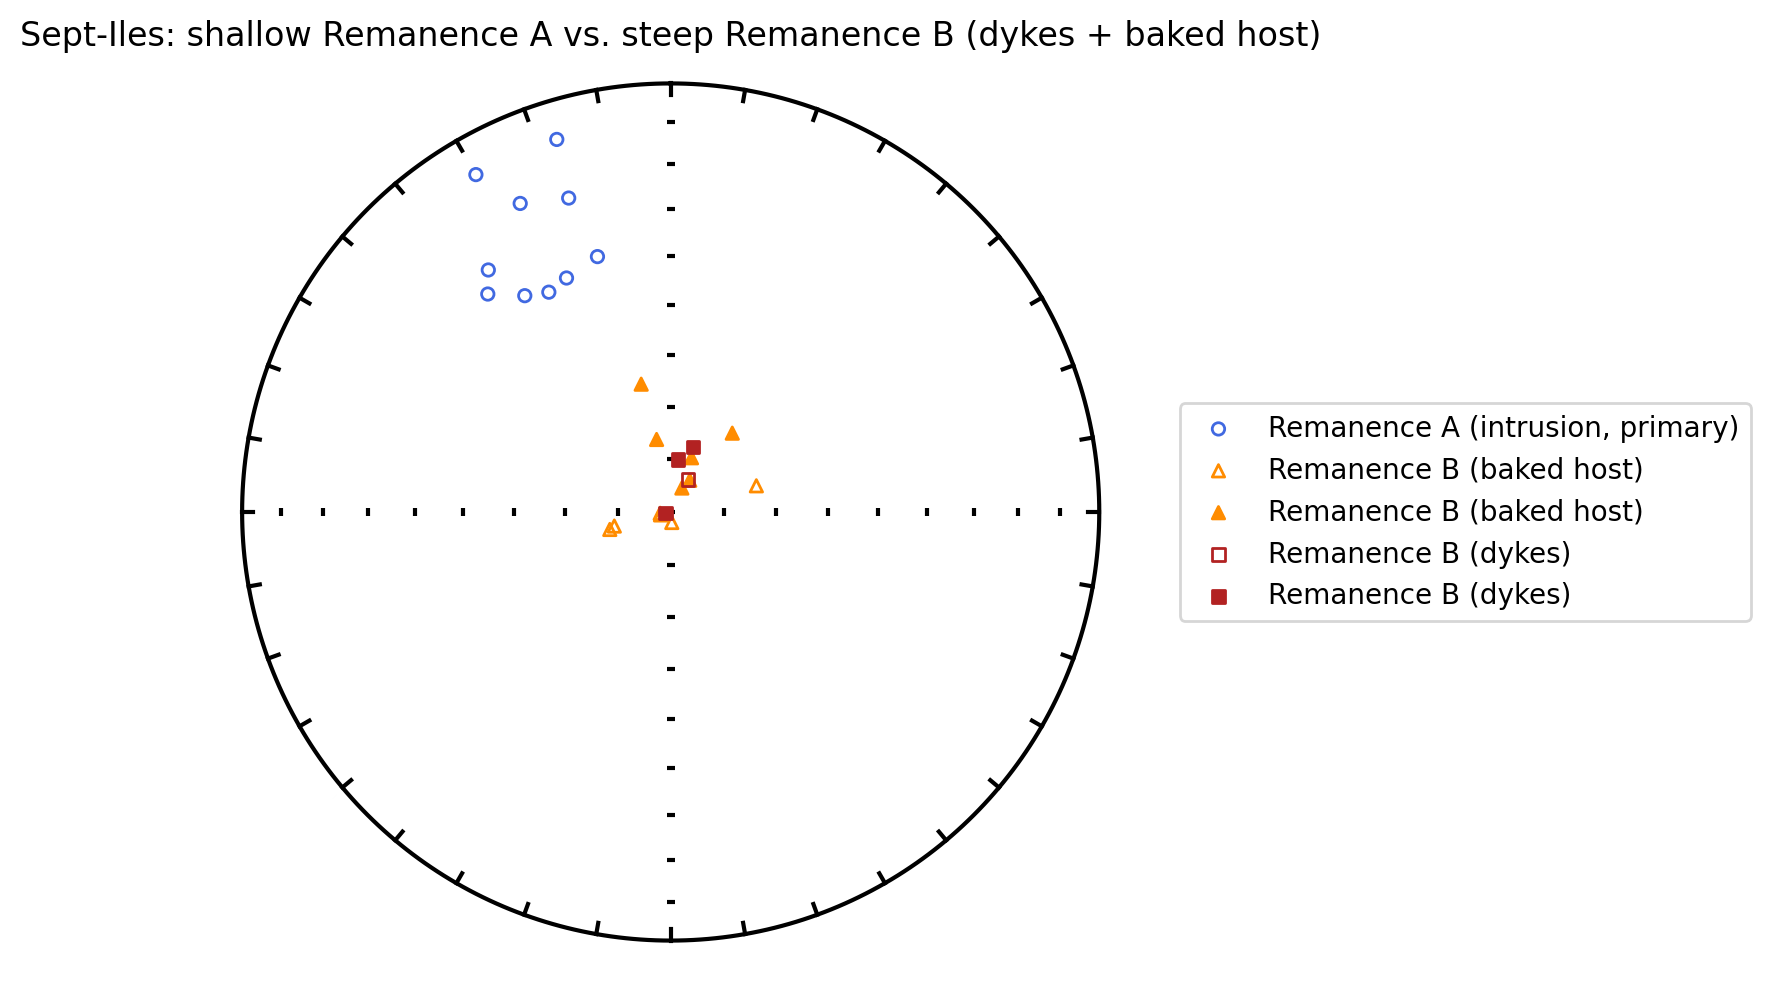

In [7]:
ipmag.plot_net()
A_blk = A
ipmag.plot_di(A_blk['dir_dec'].tolist(), A_blk['dir_inc'].tolist(),
              color='royalblue', marker='o', label='Remanence A (intrusion, primary)')
for comp, color, mk, lab in [('B-host', 'darkorange', '^', 'Remanence B (baked host)'),
                             ('B-dyke', 'firebrick', 's', 'Remanence B (dykes)')]:
    sub = sites_geo[sites_geo['dir_comp_name'] == comp]
    ipmag.plot_di(sub['dir_dec'].tolist(), sub['dir_inc'].tolist(), color=color, marker=mk, label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('Sept-Iles: shallow Remanence A vs. steep Remanence B (dykes + baked host)')
plt.show()

## Why we rely on Component A alone (Bono & Tarduno, 2015)

Tanczyk et al. (1987) reported two nearly orthogonal directions (shallow A, steep
B). Bono & Tarduno (2015) evaluated which can be considered primary using single-silicate-crystal
paleomagnetism of Sept-Iles anorthosite feldspars, whose magnetization is carried
by minute single-domain magnetite inclusions with billion-year relaxation times —
ideal recorders that exclude the unstable multidomain grains that contaminate
whole-rock samples. They conclude that only the shallow direction (Component A) is
carried by single-domain grains and can be considered primary; the steep
direction (Component B) has soft, multidomain magnetic character (largely removed
by ~20 mT) and is interpreted as a young secondary overprint. The shallow Component A is itself of dual polarity, and interpreted to record a reversing
geomagnetic field during cooling.

Additionally, the Component A direction has an inverse baked contact test with the Component B direction.

Accordingly, the Sept-Iles paleomagnetic pole that has been given a rating in the Nordic Workshop compilations is that of  Component A alone.

## Paleosecular variation

A_95 of 6.5 passes Deenen et al. (2011) criteria of being between 4.8 and 19.2 for this number of sites


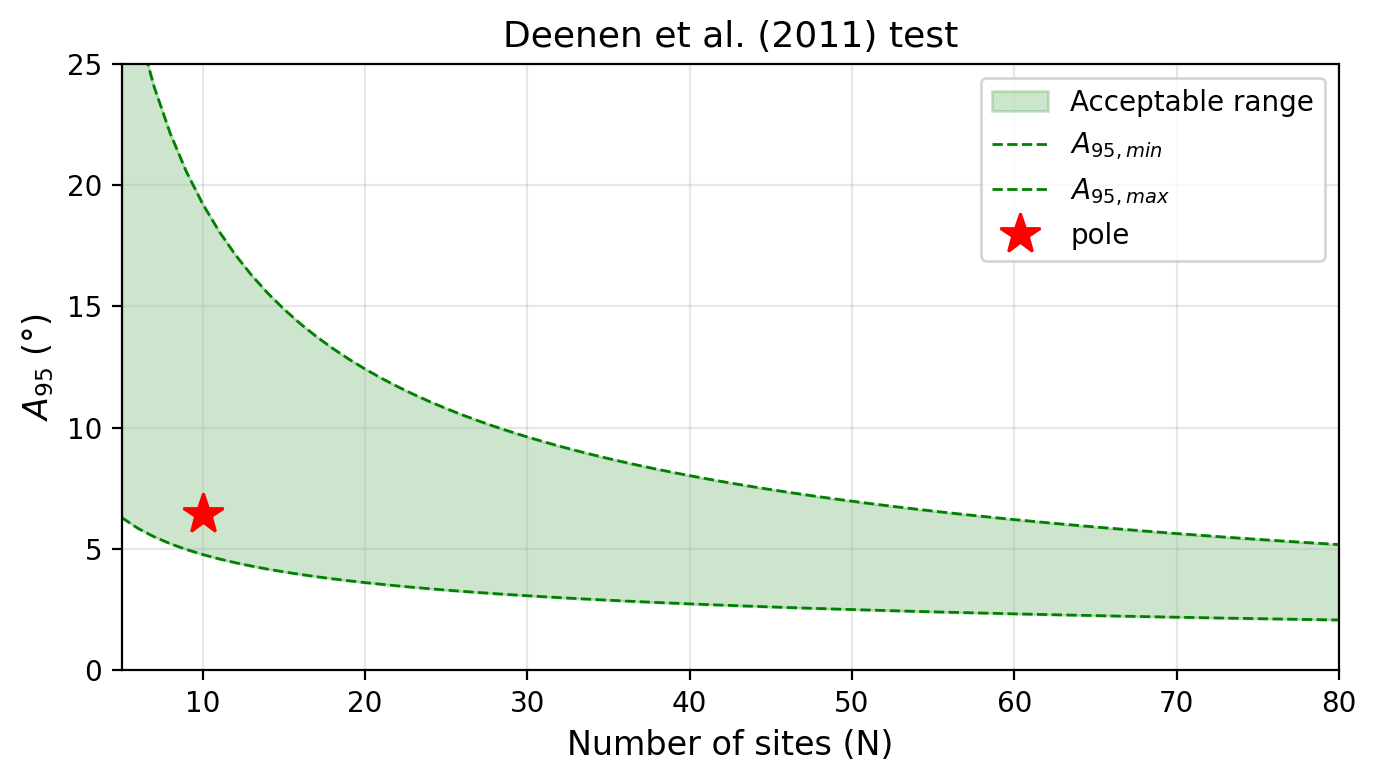

In [8]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)
plt.show()

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

{'Mode': 'Mode 1',
 'Dec': np.float64(141.1739155910263),
 'Inc': np.float64(19.671673631238804),
 'N': 10,
 'Mu': np.float64(0.6883728096121952),
 'Mu_critical': 1.207,
 'Me': np.float64(1.2810423226460848),
 'Me_critical': 1.094,
 'Test_result': 'Fisher distribution rejected'}

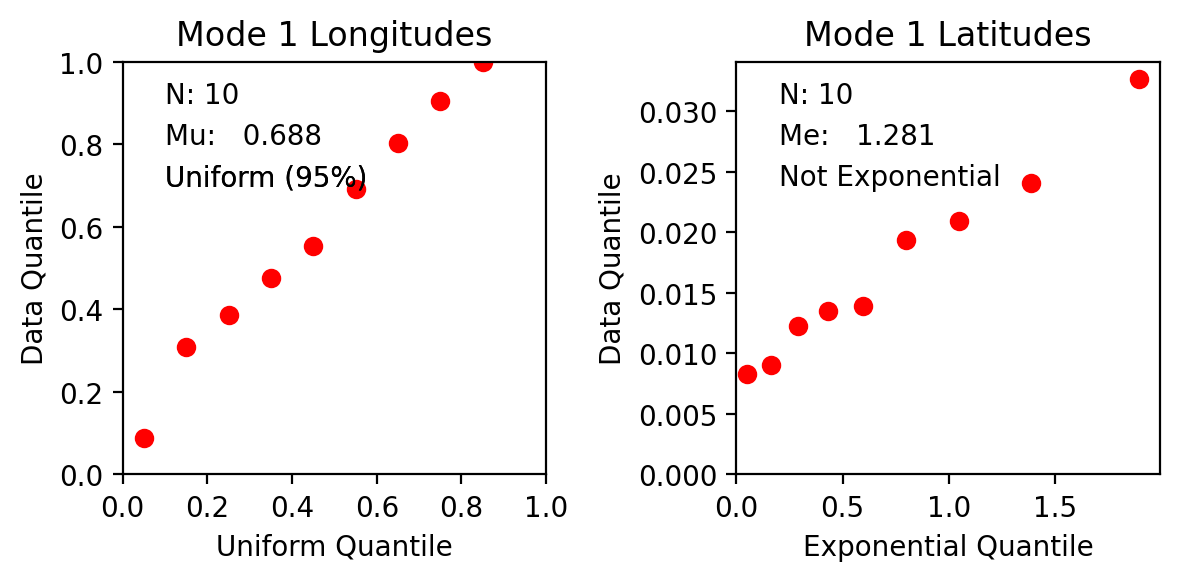

In [9]:
fishqq_result = pt.fishqq_vgps(A, unify_polarity=False)
fishqq_result

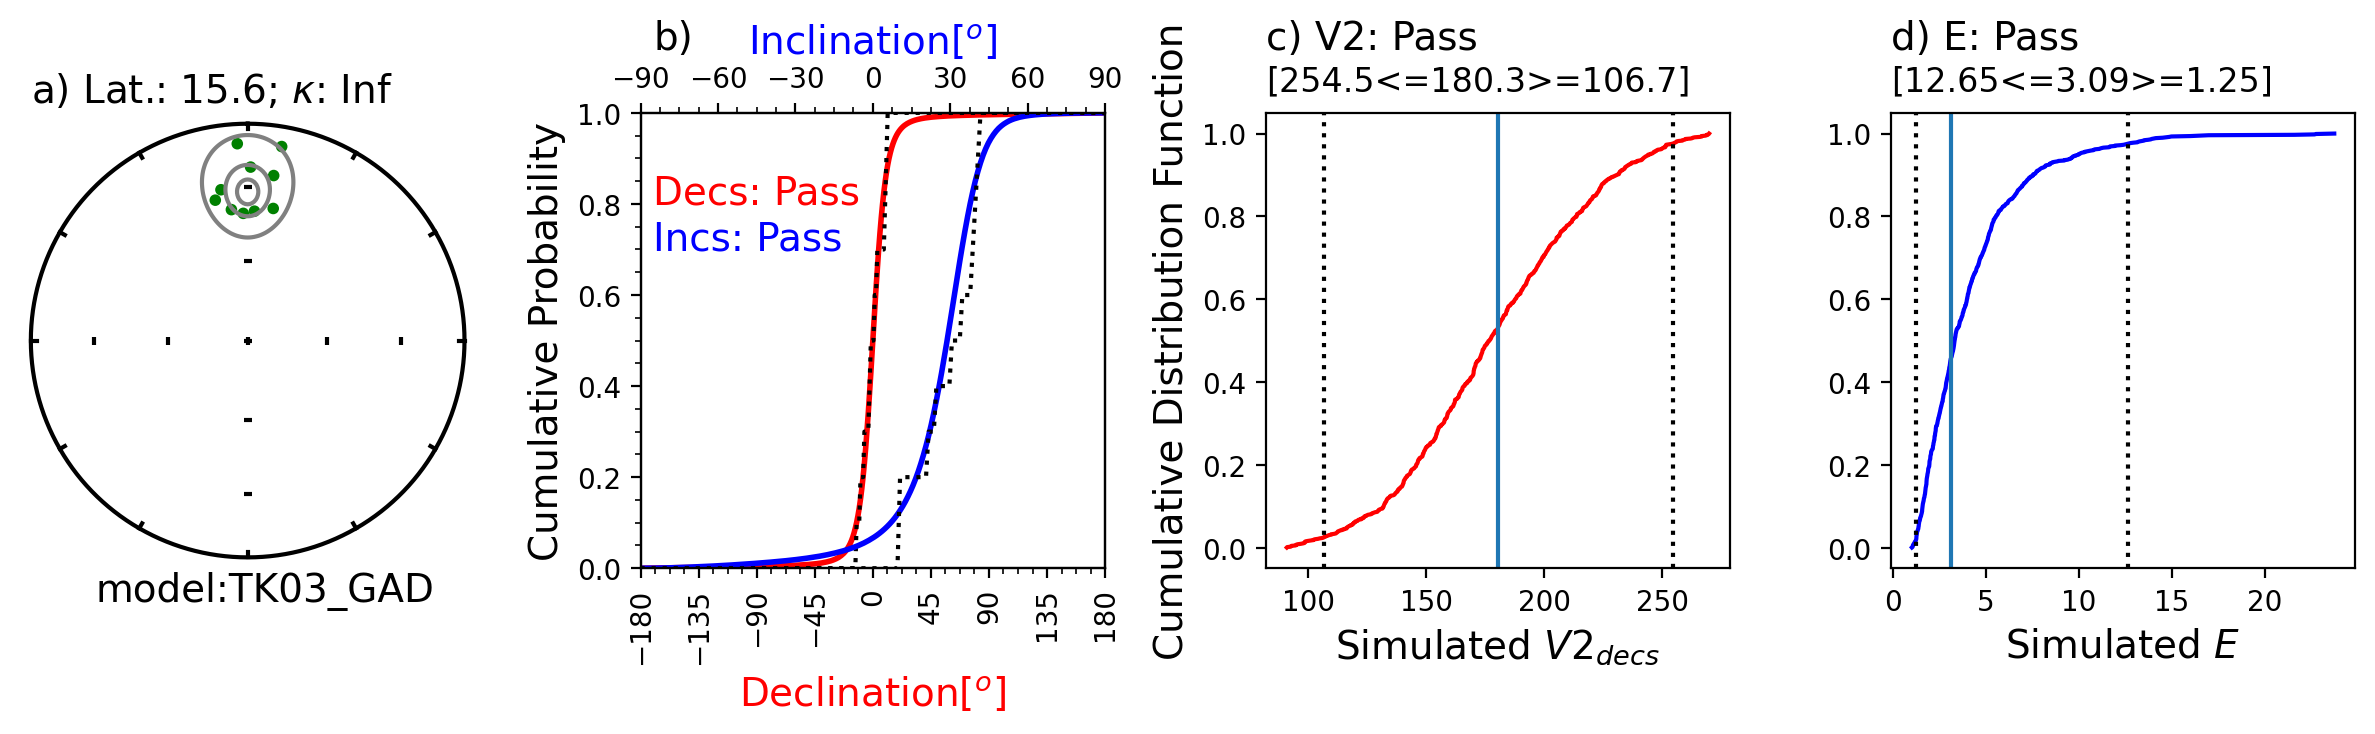

paleolatitude = 15.6 deg; elongation E = 3.09 (consistent with TK03.GAD)


In [10]:
_slat, _slon = float(A['lat'].mean()), float(A['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(A, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(A, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The Sept-Iles pole in the context of the Laurentia APWP

The A-component pole is shown in both polarity conventions for comparison: the
southern convention of the prior compilation (−20°/321°E) and the flipped
northern polarity (+20°/141°E). The northern polarity lies with the
Neoproterozoic–Ediacaran segment of the Laurentia APWP, while the southern
convention places it at the antipode.

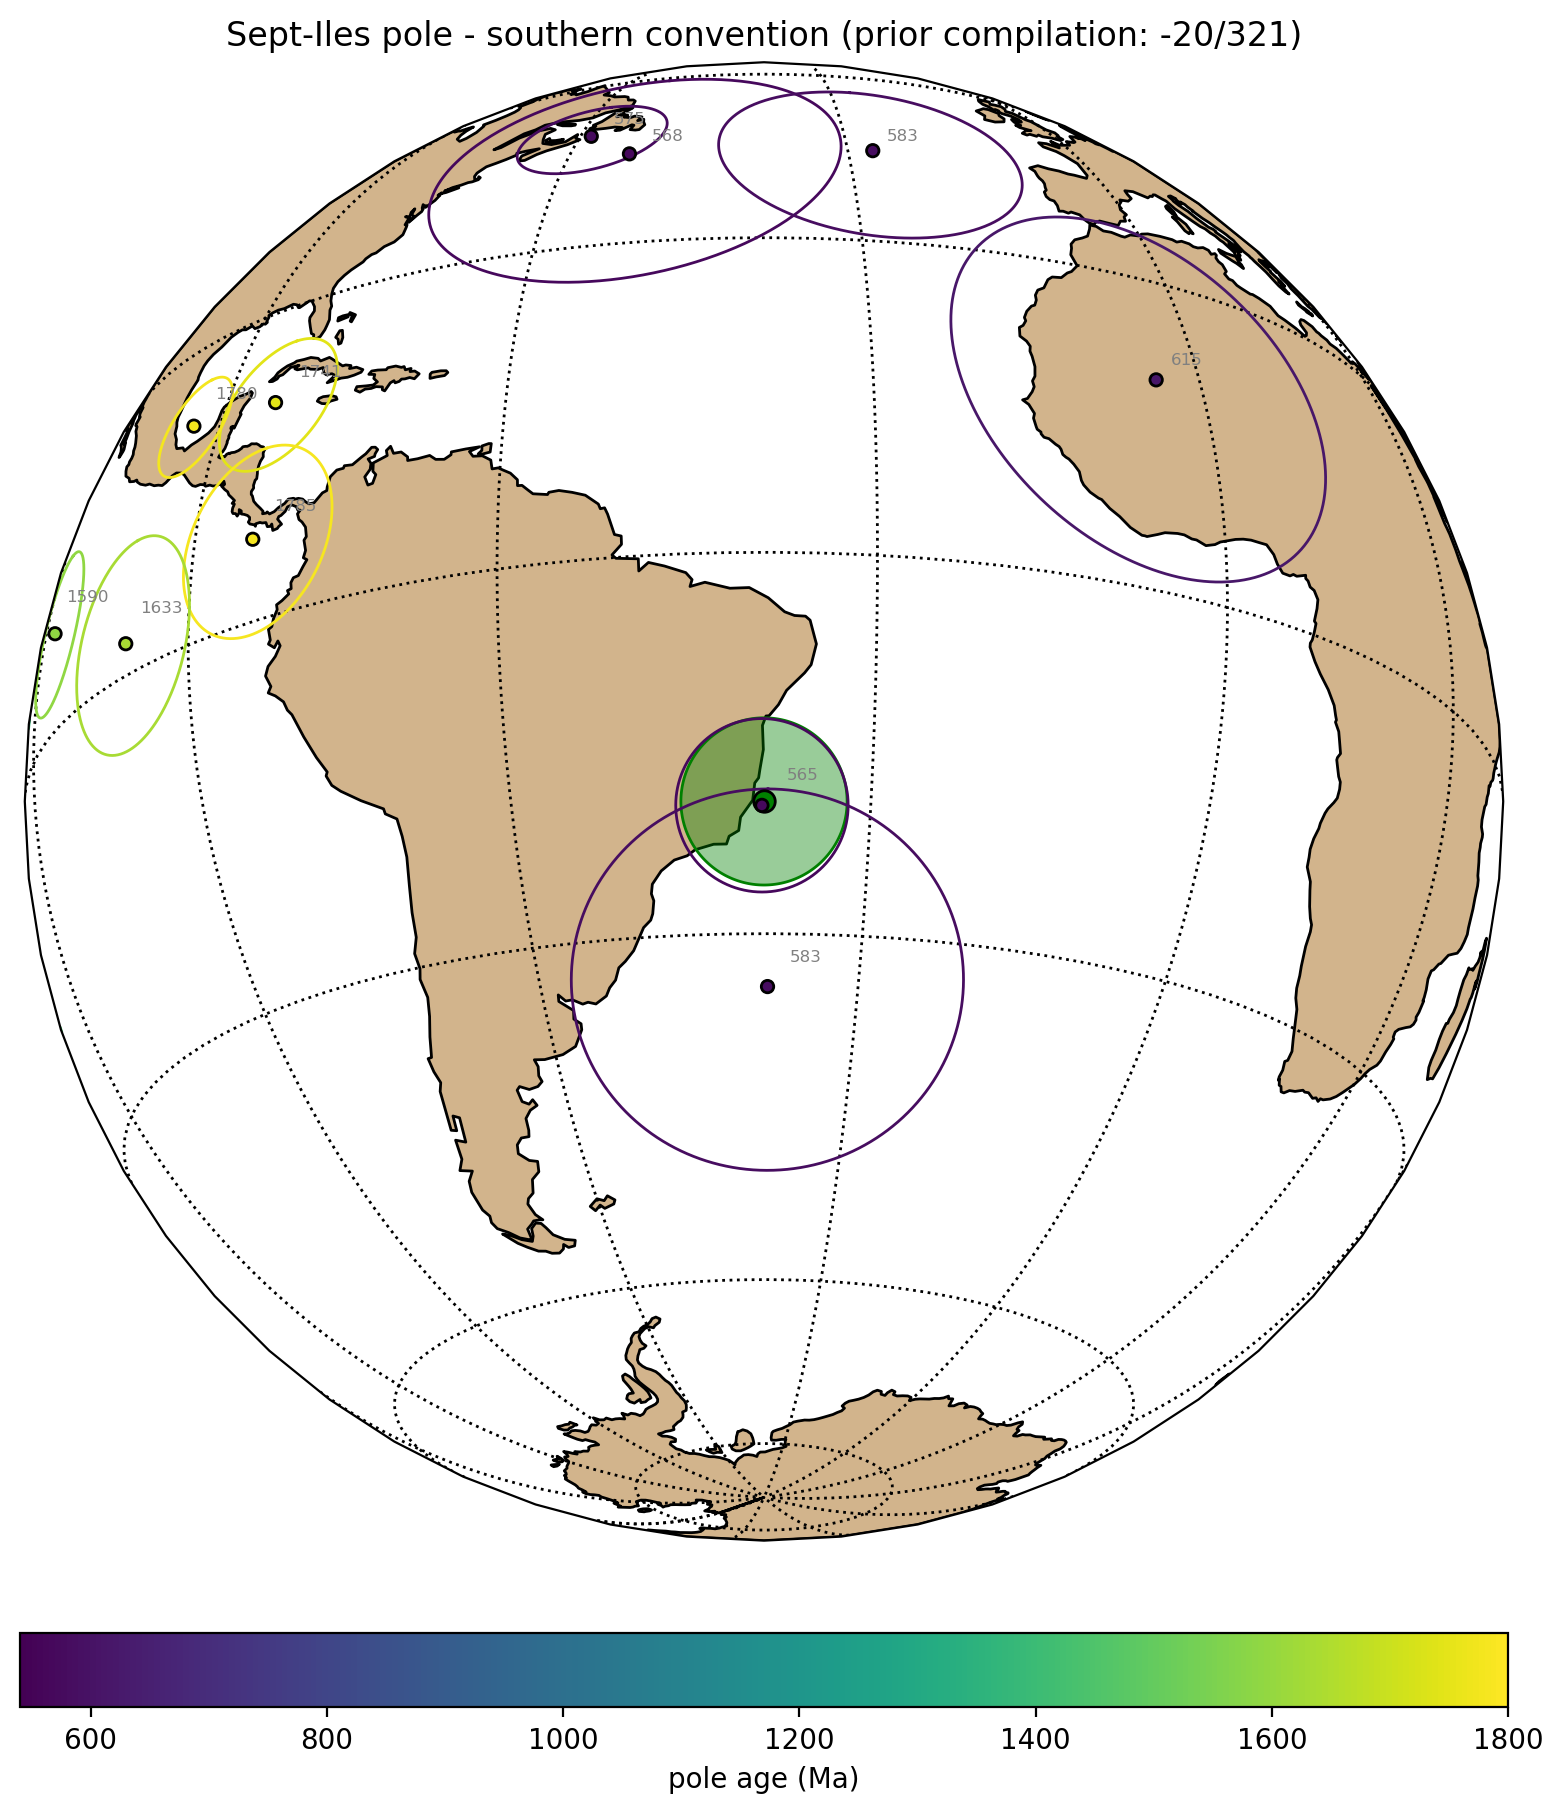

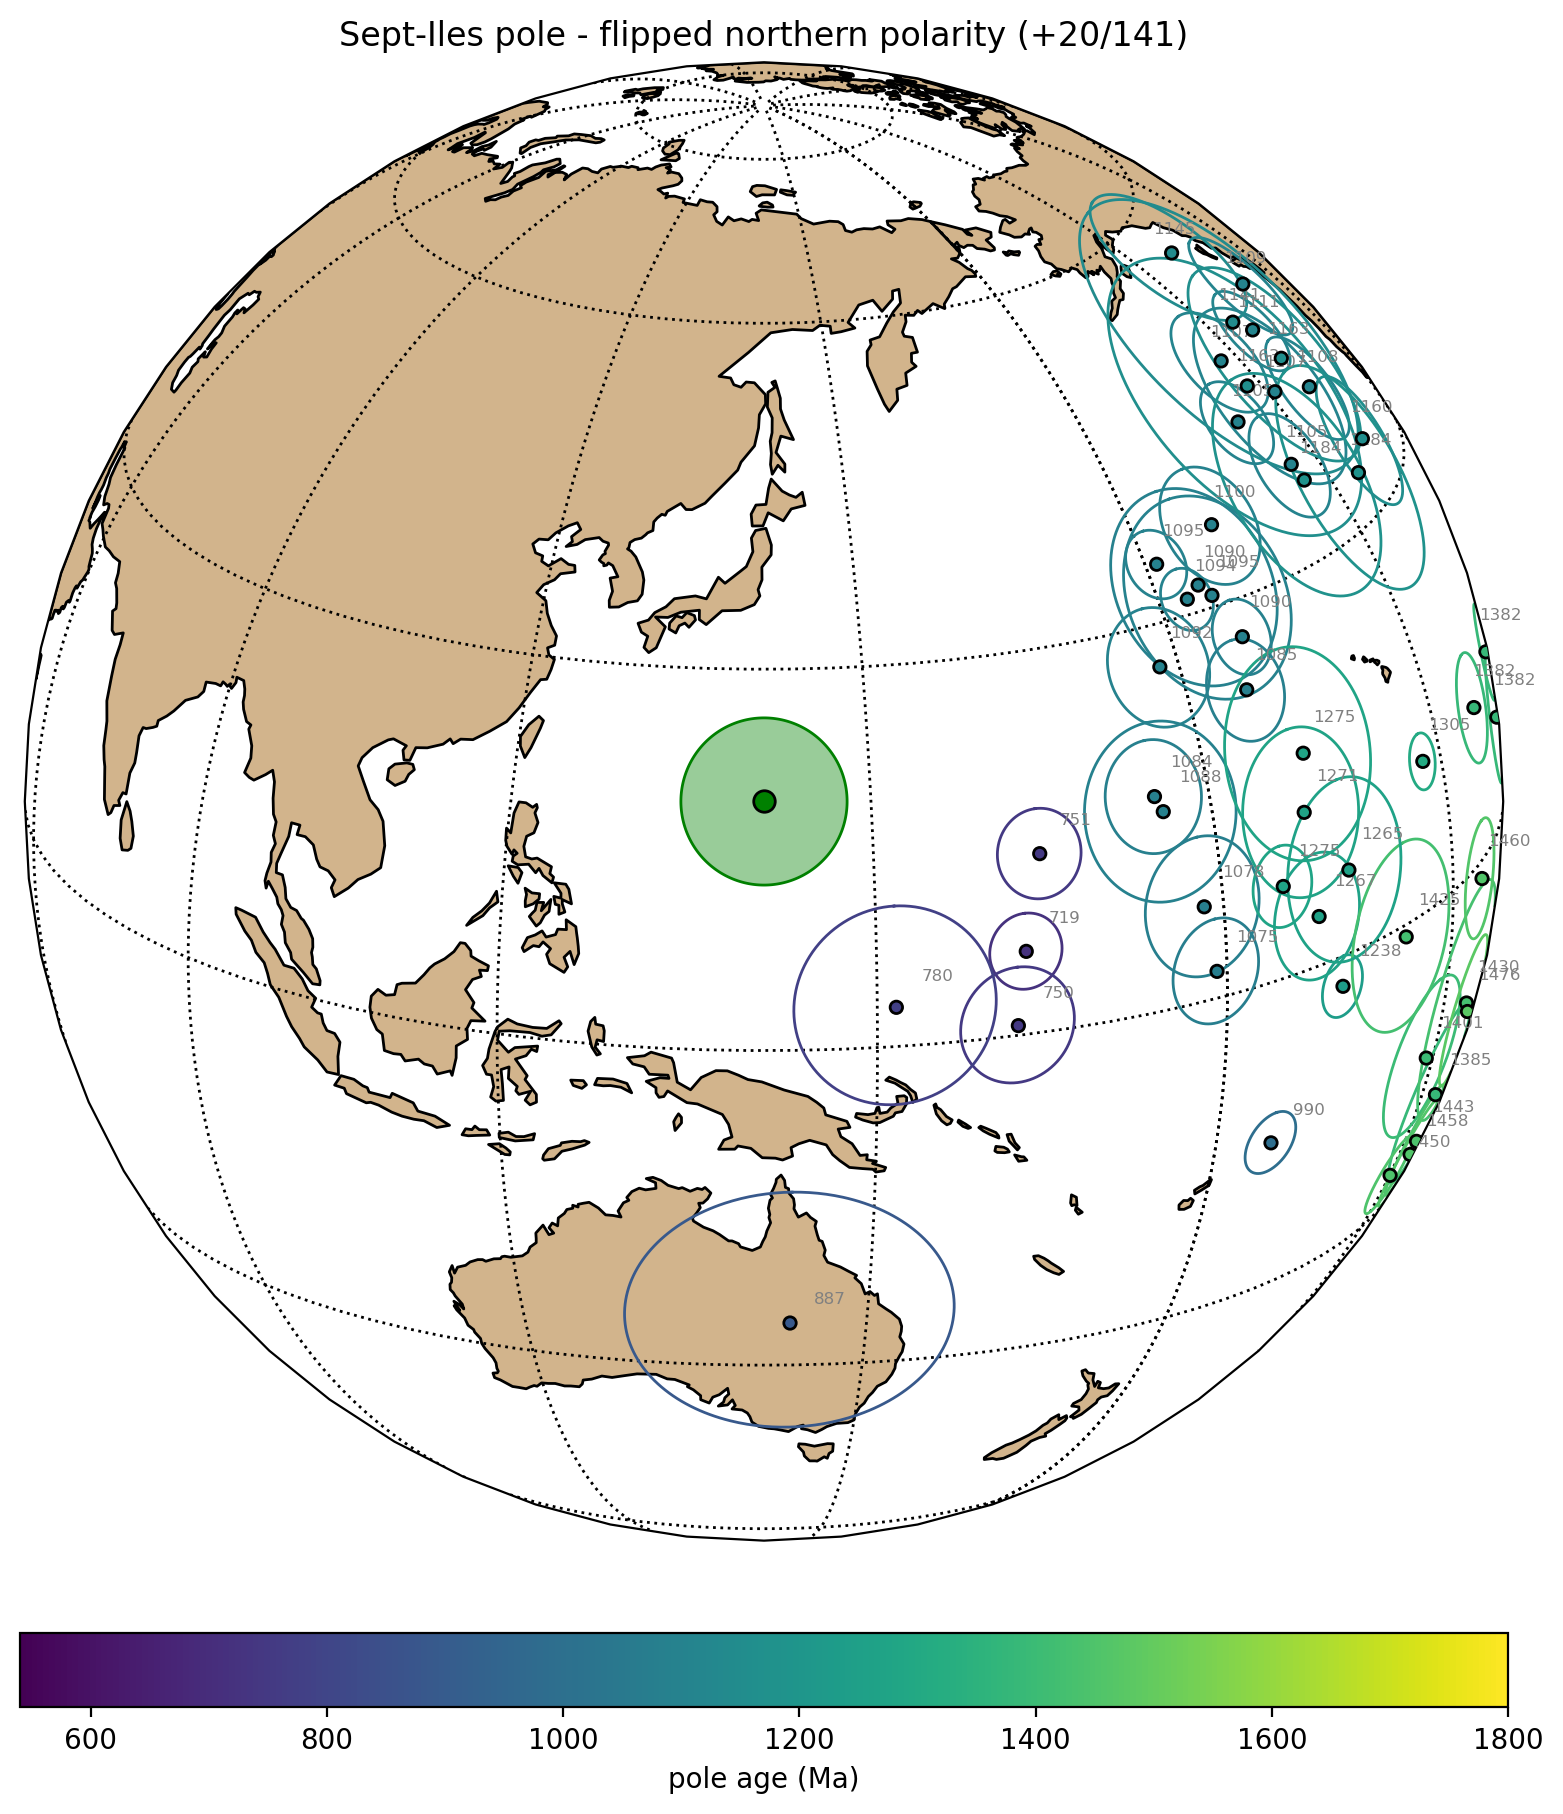

In [11]:
Laurentia_poles = pt.get_Laurentia_poles()
# show the A-component pole in both polarity conventions
for label, p in [('southern convention (prior compilation: -20/321)', pole_mean),
                 ('flipped northern polarity (+20/141)', pole_north)]:
    ax = pt.plot_apwp_context(Laurentia_poles, p['inc'], p['dec'], p['alpha95'],
                              age_min=540, age_max=1800, projection='orthographic',
                              central_longitude=p['dec'], central_latitude=p['inc'])
    ax.set_title(f'Sept-Iles pole - {label}')
    plt.show()

## R7: comparison with younger Laurentia poles

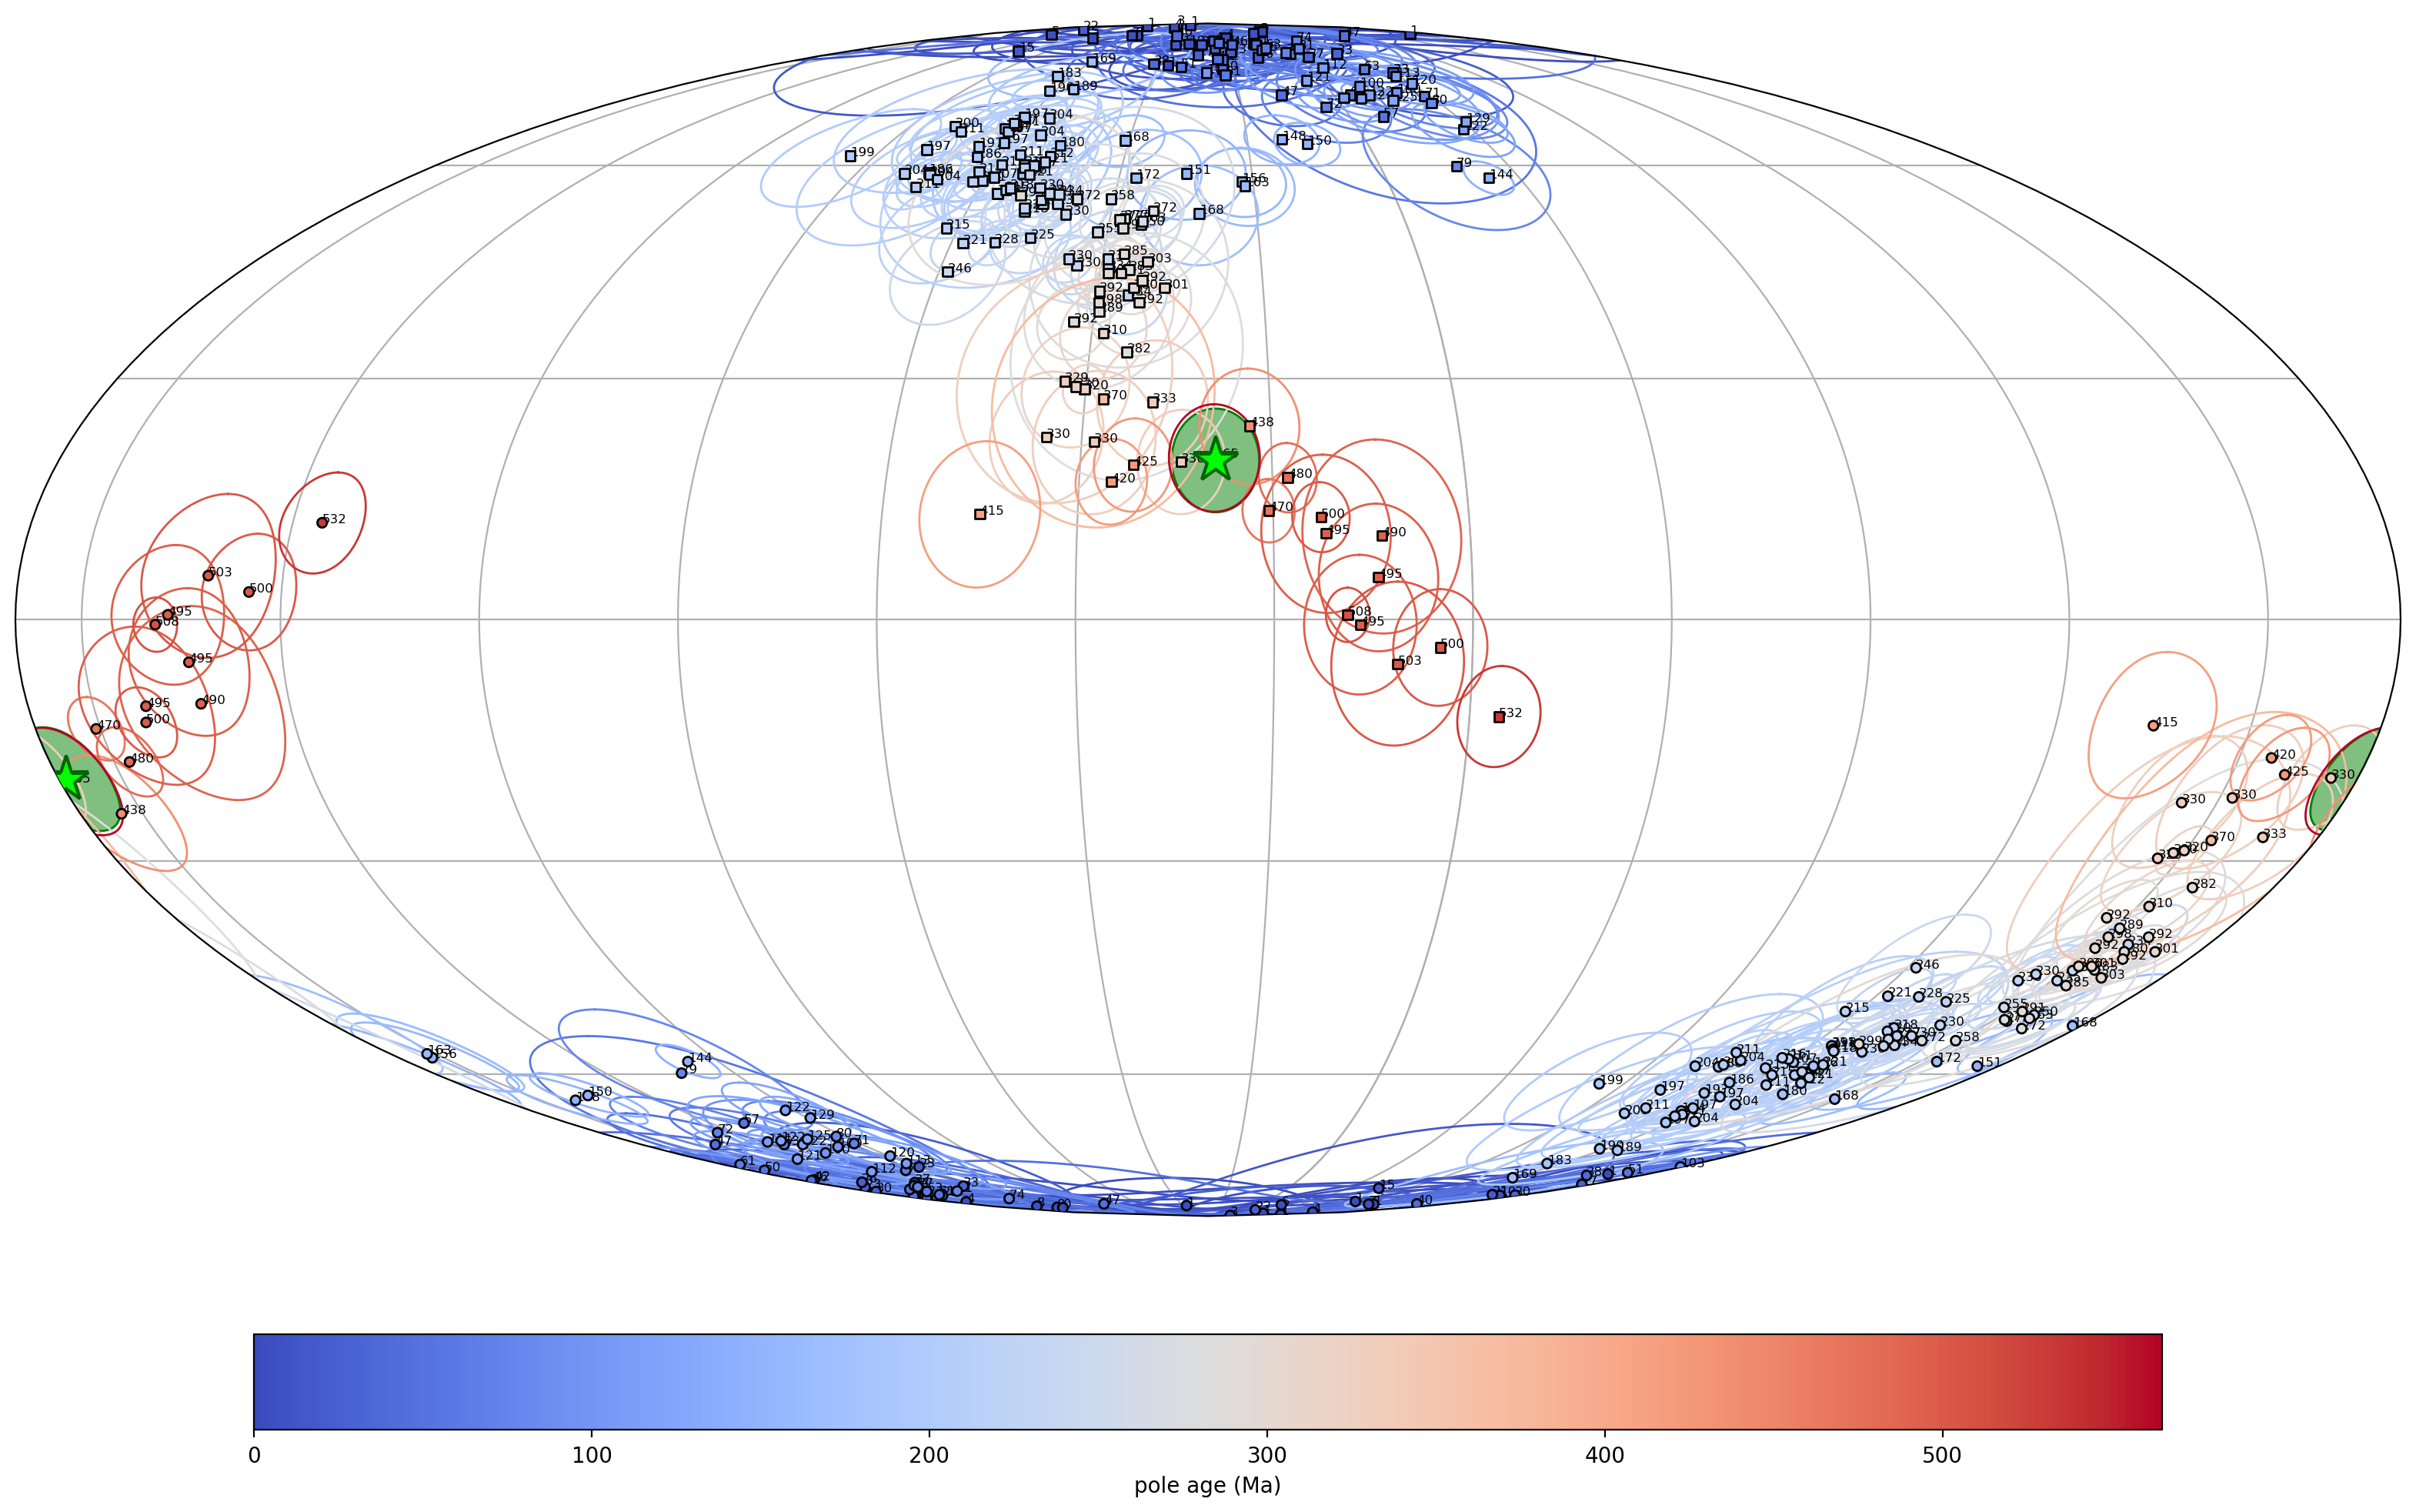

<GeoAxes: >

In [12]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Sept-Iles Layered Intrusion', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=565)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | 565 ± 4 Ma weighted mean of 207Pb/206Pb dates from two zircon grains dated via U-Pb ID-TIMS in Higgins and van Breemen, 1998 (https://doi.org/10.1086/516033). A third grain was dated and rejected from the weighted mean. |
| 2 | Techniques and statistical analysis | **1** | Thermal + AF demagnetization; N = 51 samples (≥ 25), B = 10 sites (≥ 8), K = 34 (10-70) — meets the PSV-sampling thresholds. |
| 3 | Magnetic mineralogy characterized | **1** | Remanence A carried by fine-grained magnetite (unblocking 550-580 °C); single-crystal magnetite inclusions confirmed by Bono & Tarduno (2015). Polished thin section and microprobe studies by Higgins (1979) have detected the presence of fine-grained magnetite throughout the basic phases. |
| 4 | Field tests constrain age of magnetization | **c** | Positive inverse baked-contact test: the intrusion retains Remanence A away from the cross-cutting dykes, which carry (and bake the host to) Remanence B. |
| 5 | Structural control / tectonic coherence | **0** | A single layered intrusion treated in situ (no independent tilt control or distributed structural test). |
| 6 | Presence of reversals | **0** | Component A was reported as a single polarity by Tanczyk et al. (1987) (the dual polarity shown in Bono & Tarduno (2015) single-crystal work who do not report directional data and whose reversal test is based on pre-filtering data into quadrants). |
| 7 | No resemblance to younger poles | **0** | The Component A pole is close to Ordovician and Silurian Laurentia poles the age of the crosscutting dike on which the inverse baked contact test was conducted is not constrained. |
| | Total | **4/7** | Grade B |

## Nordic workshop summary

The Sept-Iles pole is the Component A pole recreated from the 10 gabbro/
anorthosite site VGPs of Tanczyk et al. (1987): −20°/321° (= 20°N/141°E),
A95 6.7°, reproducing the prior compilation (GPMDB 1752). The steep Remanence B
is excluded as an interpreted secondary, dyke/contact-related overprint, justified
by the
positive inverse baked-contact test (Tanczyk et al., 1987) and by the
single-silicate-crystal analysis of Bono & Tarduno (2015), which shows that only
the shallow Component A is carried by single-domain magnetite interpreted as
primary (the steep component interpreted as a young multidomain overprint that
fails a reversal test).

In [13]:
septiles_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Sept-Iles Layered Intrusion',
    sites=A,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Component A',
    tests='C*+ (positive inverse baked-contact test: intrusion retains Remanence A away from the cross-cutting dykes, which carry Remanence B)',
    gpmdb_number='1752',
    percent_reversed=0,
    demag_code=4,
    R1=1, R2=1, R3=1, R4='c', R5=0, R6=0, R7=0, Grade='B',
    nominal_age=565, lomagage=561, himagage=569,
    REF_method='U-Pb zircon age 565 +/- 4 Ma (weighted mean of 207Pb/206Pb dates on granophyric zircon within the layered gabbros; Higgins & van Breemen, 1998).',
    POLE_AUTHORS='Tanczyk, E. I., Lapointe, P., Morris, W. A., & Schmidt, P. W.',
    YEAR=1987,
    JOURNAL='Canadian Journal of Earth Sciences',
    VOLUME='24',
    VPAGES='1431-1438',
    TITLE='A paleomagnetic study of the layered mafic intrusion at Sept-Iles, Quebec',
    COMMENT='Challenge with this direction is that it overlaps with the Ordovician/Silurian APWP of Laurentia which would be the expected time of remagnetization associated with Taconic/Salinic orogeny. The steep Remanence B (dykes + baked host, pole 59S/116E) is not included in the compilation given suspicion of remagnetization. Pole calculated from site VGPs in Swanson-Hysell et al., 2026.'
)
pt.save_nordic_summary(septiles_summary, '565_Sept_Iles')
septiles_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Sept-Iles Layered Intrusion,GPMDB:1752,Component A,C*+ (positive inverse baked-contact test: intr...,0,50.2,293.5,10,51,...,569,U-Pb zircon age 565 +/- 4 Ma (weighted mean of...,Sept-Iles Layered Intrusion,"Tanczyk, E. I., Lapointe, P., Morris, W. A., &...",1987,Canadian Journal of Earth Sciences,24,1431-1438,A paleomagnetic study of the layered mafic int...,Challenge with this direction is that it overl...


## Comparison with the published pole of Tanczyk et al. (1987)

The mean pole reported here is computed as the **Fisher mean of the individual site VGPs** (`pt.compute_mean_pole`): each site mean direction is first converted to its own virtual geomagnetic pole, and those VGPs are then averaged. The pole's uncertainty is therefore the **circular** A95 of the VGP distribution (so dp = dm = A95). Tanczyk et al. (1987) instead converted the single mean **direction** to a pole, which maps the directional α95 onto an **elliptical** confidence region with unequal semi-axes dp (along the site-to-pole great circle) and dm (perpendicular to it). The Nordic compilation preserves that published ellipse (dp = 5°, dm = 9°), and its circular A95 = 6.7° ≈ √(dp·dm).

The two approaches recover the same direction (333°/−29°), the same precision (k ≈ 34), and the same pole position to within a few tenths of a degree; they differ only in how the confidence region is expressed (circular A95 from the VGP scatter here, versus the oval dp/dm from the direction-to-pole conversion in the paper). Note that Tanczyk et al. (1987) report the Remanence A pole in the opposite polarity, at 20.0°N, 141.0°E; this is the antipode of the −20°N, 321°E position used here and in the compilation, and is the same pole.

| Quantity | This study (site VGPs) | Tanczyk et al. (1987), Table 3a | previous Nordic compilation |
|---|---|---|---|
| N (sites) | 10 | 10 | 10 |
| Dec (°) | 333.1 | 333 | 333 |
| Inc (°) | −29.0 | −29 | −29 |
| k | 33.6 | 34 | 34 |
| α95 (direction, °) | 8.5 | 8 | 8 |
| Pole lat (°N) | −19.7 | −20.0 | −20.0 |
| Pole lon (°E) | 321.2 | 321.0 | 321.0 |
| dp (°) | | 5 | 5 |
| dm (°) | | 9 | 9 |
| A95, pole (°) | 6.5 | — (oval dp/dm only; √(dp·dm) ≈ 6.7) | 6.7 |